# 02 – Data Exploration: MMS Ion Spectra

**Purpose:** Load a pre-processed MMS dataset, visualise the raw ion spectra for each plasma region, inspect class balance, and use PCA to understand how much variance can be captured as a function of window length.

> This notebook accompanies the *Data Exploration & Dimensionality Reduction* lecture. It is designed to be run alongside the slides — each section maps to a lecture segment.

## Learning Objectives

By the end of this notebook you will be able to:

- Load a `SpectrumDataset` from a NetCDF file and understand its structure.
- Visualise MMS ion energy spectra and identify characteristic patterns for each plasma region.
- Recognise class imbalance and explain why it matters for ML.
- Explain why global scaling (log or minmax) is needed before applying PCA to spectral data, and why per-feature standardisation should be avoided.
- Apply PCA to high-dimensional spectral data and interpret a scree plot and cumulative-variance curve.
- Explain how window length affects the intrinsic dimensionality of the data.
- Visualise and physically interpret principal component vectors reshaped as spectrograms.

## Background

The MMS spacecraft measures the flux of ions arriving at the detector as a function of energy (roughly 10 eV – 30 keV) roughly every 4.5 seconds. A single measurement is therefore a vector with one entry per energy bin – already a relatively high-dimensional object. When we stack many consecutive measurements into a *time window* (say, 10 minutes worth), the resulting "sample" is a 2-D matrix of shape `(time_steps, energy_bins)`.

The four plasma regions MMS traverses have strikingly different spectral signatures:

| Label | Region | Spectral fingerprint |
|-------|--------|---------------------|
| 0 | Solar Wind | Narrow, high-energy peak |
| 1 | Ion Foreshock | Similar to SW but with an extended high-energy tail |
| 2 | Magnetosheath | Broad, medium-energy peak |
| 3 | Magnetosphere | Linearly increasing signal with energy |

Our goal is to check whether these differences are visible by eye, and then to ask a quantitative question: *how many dimensions do we actually need* to represent this data? That is the job of **Principal Component Analysis (PCA)**.

> **Labels** used throughout this notebook come from the automated classification by Olshevsky et al. (2024), which achieved >97 % agreement with expert-labelled data.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from spacephyml.datasets.mms import SpectrumDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from pathlib import Path

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_theme()

figure_path = Path('./figures')
figure_path.mkdir(exist_ok=True)

RANDOM_STATE = 42
NC_FILE = 'data/data_cleaned.nc'

REGION_NAMES = {0: 'Solar Wind', 1: 'Ion Foreshock', 2: 'Magnetosheath', 3: 'Magnetosphere'}
PALETTE      = dict(zip(REGION_NAMES.values(), sns.color_palette('tab10', 4)))

## 1 · Load the Dataset

`SpectrumDataset` reads a NetCDF file and divides the time series into **non-overlapping windows** of `N` consecutive measurements (cadence ≈ 4.5 s, so `N = 133` ≈ 10 minutes). Every window gets the majority label of its constituent measurements, so each sample represents a short interval when the spacecraft was firmly inside one plasma region.

Setting `flatten=False` keeps each sample as a 2-D array `(N, n_energy_bins)`, which is useful for visualisation. We will switch to `flatten=True` later when feeding data into PCA.

In [2]:
N = 133  # ≈ 10 minutes at 4.5 s cadence

ds = SpectrumDataset(
    dataset_path=NC_FILE,
    trange=None,       # e.g. ('2017-11-01', '2017-11-02') to restrict time
    N=N,
    samples=None,      # None = use all available windows
    data_columns=None, # auto-detect the (time, energy_bin) variable
    flatten=False,     # keep 2-D (N, n_bins) tensors for visualisation
    verbose=True,
    fill_unknown=True, #Allow some "unknown" labels in windows if surronding labels are the same
)

print(f'Total samples: {len(ds)}')

Max number of samples per classification is: 222
Total samples: 2331


## 2 · Visualise Ion Spectra by Region

Each panel below shows an ion energy spectrogram for one window. Time runs along the x-axis; energy (eV) on the y-axis; colour encodes differential energy flux. Two example windows are shown per region so you can get a feel for intra-class variability.

Look for the spectral fingerprints described in the Background section – they are often strikingly clear even in a short 10-minute window.

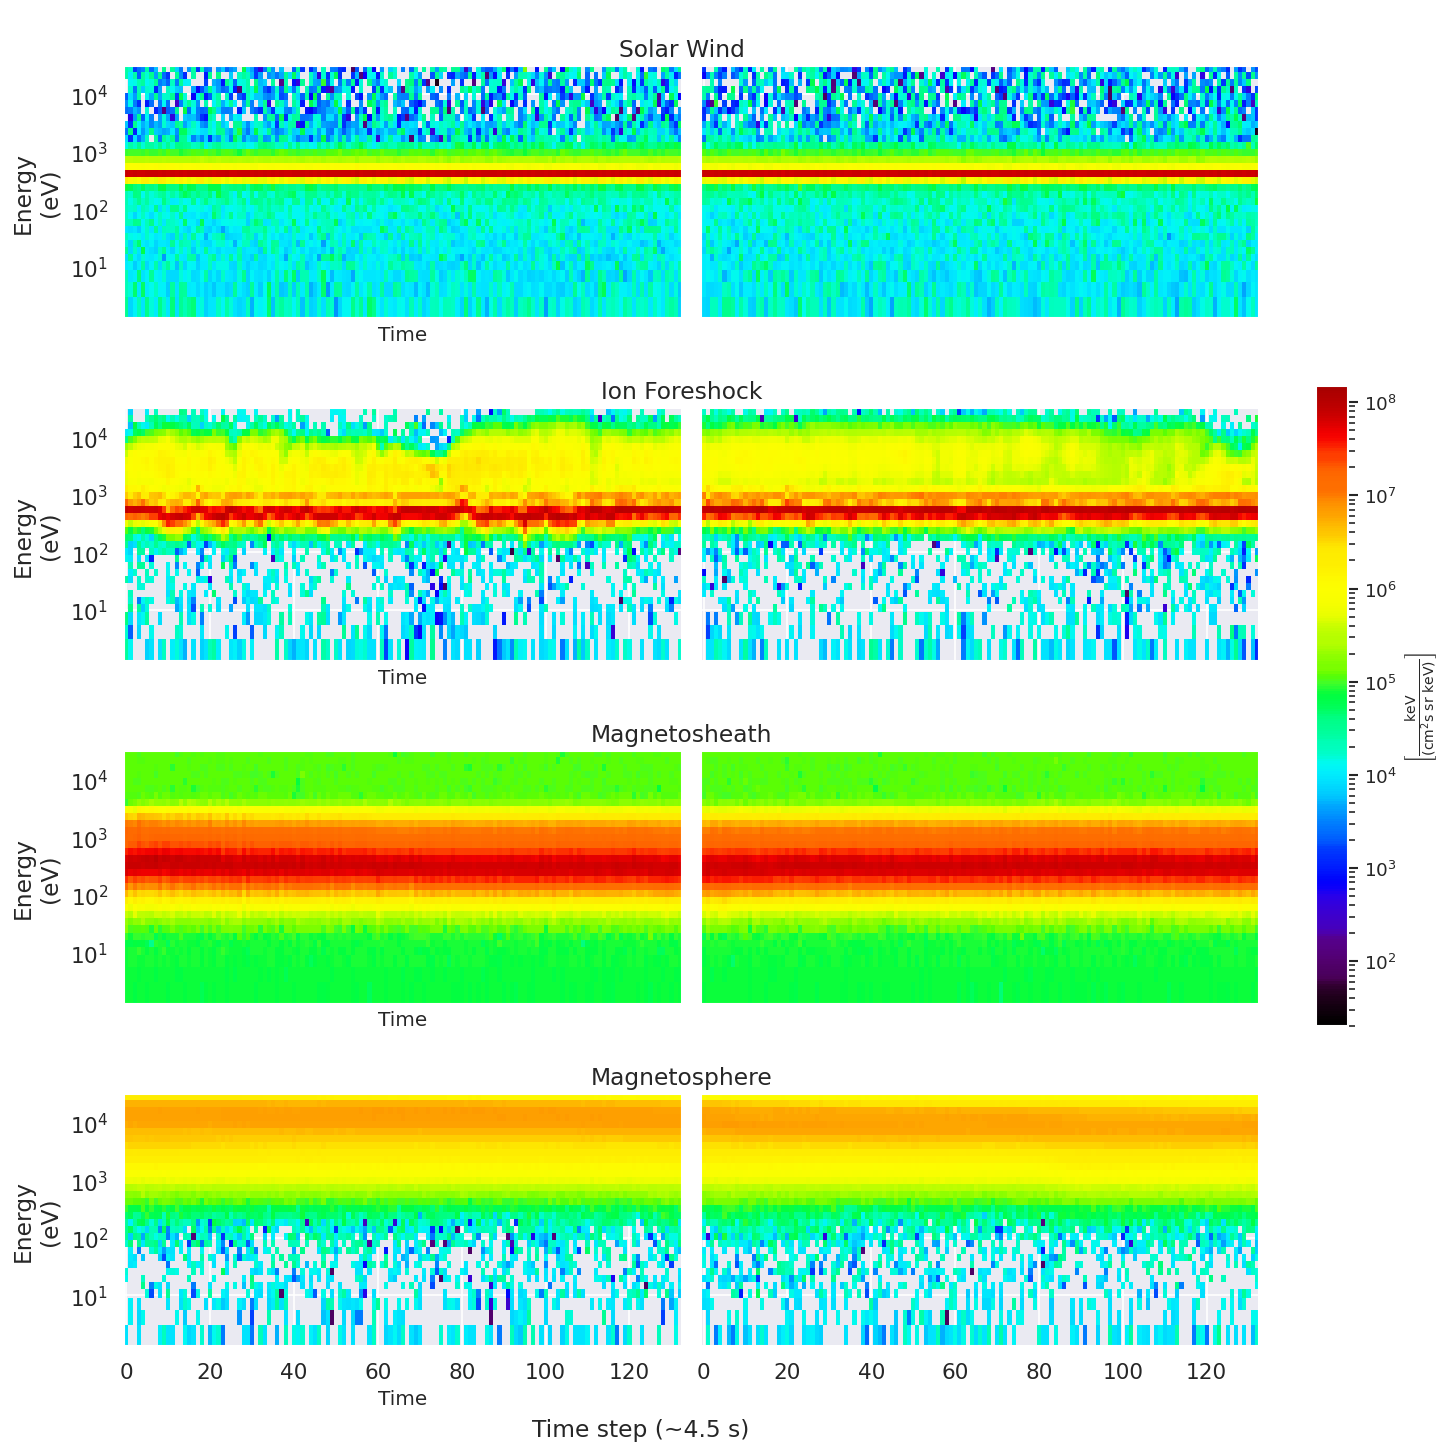

In [3]:
from utils.plot_functions import spectrum_plot

spec_lev = ds.bin_centers[0, 0]   # energy bin centres, shape (n_bins,)
spec_m, spec_l = ds[:]

EXAMPLE_IDXS = [0, 1]  # which windows to show per region
zlim = [20, 1.5e08]

fig, axes = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(12, 12), layout='constrained')
X = np.arange(N)

for row, (label, name) in enumerate(REGION_NAMES.items()):
    idxs = np.where(spec_l.numpy() == label)[0]
    axes[row][0].set_title(f'\n{name}', x=1, fontsize=14)
    for col, idx in enumerate(EXAMPLE_IDXS):
        spectrum_plot(X, spec_lev, spec_m[idxs[idx]].numpy(), ax=axes[row][col],
                      zlim=zlim, labels=(col == 0), c_bar=False)

for i, ax in enumerate(axes.ravel()):
    if i % 2 == 0:
        ax.set_ylabel('Energy\n(eV)', labelpad=5, fontsize=14)
    ax.tick_params(labelsize=13)

fig.supxlabel('Time step (~4.5 s)', x=0.44, fontsize=14)
cbar = fig.colorbar(axes[-1][-1].collections[0], ax=axes, aspect=20, shrink=0.5)
cbar.set_label(r'$\left[\frac{\text{keV}}{(\text{cm}^2 \text{s sr keV})}\right]$')
plt.savefig(figure_path / '02_region_spectrum.png', bbox_inches='tight')

> **A note on dynamic range and preprocessing**
>
> The spectrograms above make one thing immediately clear: ion flux varies by many orders of magnitude across regions. Solar Wind, Ion Foreshock, and Magnetosheath all reach peak fluxes on the order of 10⁸ (keV cm⁻² s⁻¹ sr⁻¹ keV⁻¹), while the Magnetosphere sits around 10⁶ — roughly two decades lower. Even within a single region, the flux spans several more decades across energy channels.
>
> If we feed raw flux values directly into PCA, the algorithm will be dominated by the highest-flux observations: the variance of a bin that fluctuates between 10⁷ and 10⁸ completely swamps one that varies between 10³ and 10⁴, even though both carry physically meaningful information. The result is that PC1 ends up capturing little more than "how bright is this window overall", rather than the spectral *shape* differences that actually distinguish the plasma regions.
>
> We therefore apply a global scaling before PCA. The goal is to compress the dynamic range while preserving the relative intensity profile across energy channels — the spectral shape that encodes the physics.

## 3 · Class Distribution

Before training any model it is important to know whether classes appear equally often in your data. **Class imbalance** – when one region dominates the dataset – can quietly bias a classifier: a model that always predicts "Magnetosphere" might score 60 % accuracy while being completely useless for detecting solar wind or the foreshock.

MMS spends much more time in the magnetosphere and magnetosheath than in the solar wind or foreshock, reflecting the actual orbit geometry. This imbalance means we should *balance* the dataset when training models. In the next section we address this by setting `samples=s` in `SpectrumDataset`, which draws at most `s` windows *per class*.

        Solar Wind (label 0):   965 samples
     Ion Foreshock (label 1):   222 samples
     Magnetosheath (label 2):   825 samples
     Magnetosphere (label 3):   319 samples


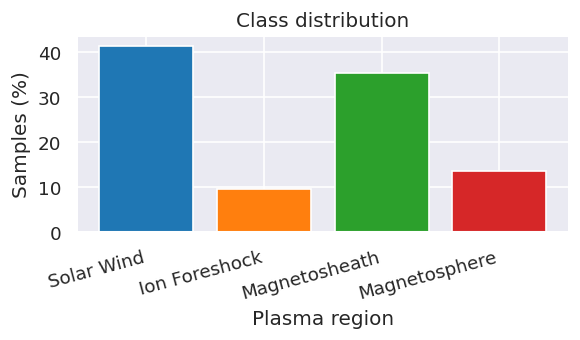

In [4]:
labels_all = np.array([ds[i][1].item() for i in range(len(ds))])
unique, counts = np.unique(labels_all, return_counts=True)

for cls, cnt in zip(unique, counts):
    print(f'  {REGION_NAMES[cls]:>16s} (label {cls}): {cnt:>5d} samples')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([REGION_NAMES[c] for c in unique], 100*counts/sum(counts),
       color=[PALETTE[REGION_NAMES[c]] for c in unique])
ax.set_xlabel('Plasma region')
ax.set_ylabel('Samples (%)')
ax.set_title('Class distribution')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

plt.savefig(figure_path / '02_dataset_plasma_region_distribution.png', bbox_inches='tight')

## 4 · PCA: How Many Dimensions Do We Need?

### Why PCA?

A flattened 10-minute window contains `N × n_bins` numbers – potentially thousands of features. Many of these will be correlated (adjacent energy bins, adjacent time steps). PCA finds a new set of orthogonal axes – **principal components** – ordered by the amount of variance they explain. We can then ask: *how many components do we need to capture most of the variance?*

### Varying the window length

A short window (1 minute) captures only the instantaneous energy distribution. A long window (20 minutes) encodes how the spectrum *evolves* over time, producing a richer but higher-dimensional sample. The **scree plot** and **cumulative explained variance** curves below show how this trade-off plays out. To keep the comparison fair we balance classes, drawing at most `max_samples` windows per class.

Before running PCA we need to compress the ~8-decade dynamic range of ion flux — otherwise a few high-flux observations dominate all principal components. The preprocessing options are described below.

### Choosing a preprocessing strategy

Two approaches for compressing the dynamic range are compared here:

| Strategy | How | Preserves spectral shape? | Notes |
|---|---|---|---|
| `'log10p1'` | `log₁₀(1 + x)` applied globally | ✓ | Maps the ~8-decade flux range to a compact [0, ~8] interval; handles zeros; the base-10 log is natural here since flux is conventionally plotted in decades |
| `'minmax'` | Linearly maps `[FLUX_MIN, FLUX_MAX]` to `[0, 1]` globally | ✓ | Purely linear; percentile-based bounds avoid sensitivity to extreme outliers |

Both are *global* transforms: the same operation is applied to every element of the array. This means the ratio of intensities between energy channels — the spectral shape — is preserved. A per-feature transform such as `StandardScaler` would instead normalise each energy bin to zero mean and unit variance independently, erasing the profile that distinguishes the regions. We deliberately avoid that here.

In [5]:
# ── Preprocessing choice ─────────────────────────────────────────────────
SCALING  = 'log10p1'   # 'log1p' | 'minmax' | 'standard'

def preprocess(X: np.ndarray, scaling: str = SCALING) -> np.ndarray:
    if scaling == 'log10p1':
        return np.log10(1. + X)
    elif scaling == 'minmax':
        lo = np.percentile(X,  1)
        hi = np.percentile(X, 99) 
        return (np.clip(X, lo, hi) - lo) / (hi - lo)
    else:
        raise ValueError(f"Unknown scaling '{scaling}'. Choose 'log1p', 'minmax', or 'standard'.")

print(f"Default preprocessing: {SCALING}")

Default preprocessing: log10p1


### Comparing both scaling strategies

Rather than choosing one scaling up-front, we run the full window-length sweep for both `log10p1` and `minmax` and overlay the results. This lets us see directly whether the choice of scaling changes how many components are needed to represent the data, or whether it mostly shifts the absolute scale of the eigenvalues without changing the shape of the scree curve.

Solid lines / filled bars = `log10p1`; dashed lines / hatched bars = `minmax`.

In [6]:
N_COMP      = 20
N_minutes   = np.array([1, 5, 10, 20], dtype=np.int64)
N_steps     = (N_minutes * 60 / 4.5).astype(np.int64)
max_samples = [1810, 300, 120, 70]

SCALINGS = ['log10p1', 'minmax']
rows = []

for scaling in SCALINGS:
    for n_min, n_steps, s in zip(N_minutes, N_steps, max_samples):
        dsi = SpectrumDataset(
            dataset_path=NC_FILE, trange=None,
            N=n_steps, samples=s, data_columns=None,
            flatten=True, verbose=False,
            fill_unknown=True,
        )
        X_flat, _ = dsi[:]
        X_scaled = preprocess(X_flat.numpy(), scaling=scaling)

        evr = PCA(n_components=N_COMP, random_state=RANDOM_STATE).fit(X_scaled).explained_variance_ratio_
        for k, (e, c) in enumerate(zip(evr, np.cumsum(evr)), start=1):
            rows.append({'Component': k, 'Explained Variance (%)': e * 100,
                         'Cumulative (%)': c * 100,
                         'Window (min)': n_min, 'Scaling': scaling})

df_both = pd.DataFrame(rows)
df_both['Window (min)'] = df_both['Window (min)'].astype('category')

### Scree plot and cumulative explained variance — both scalings

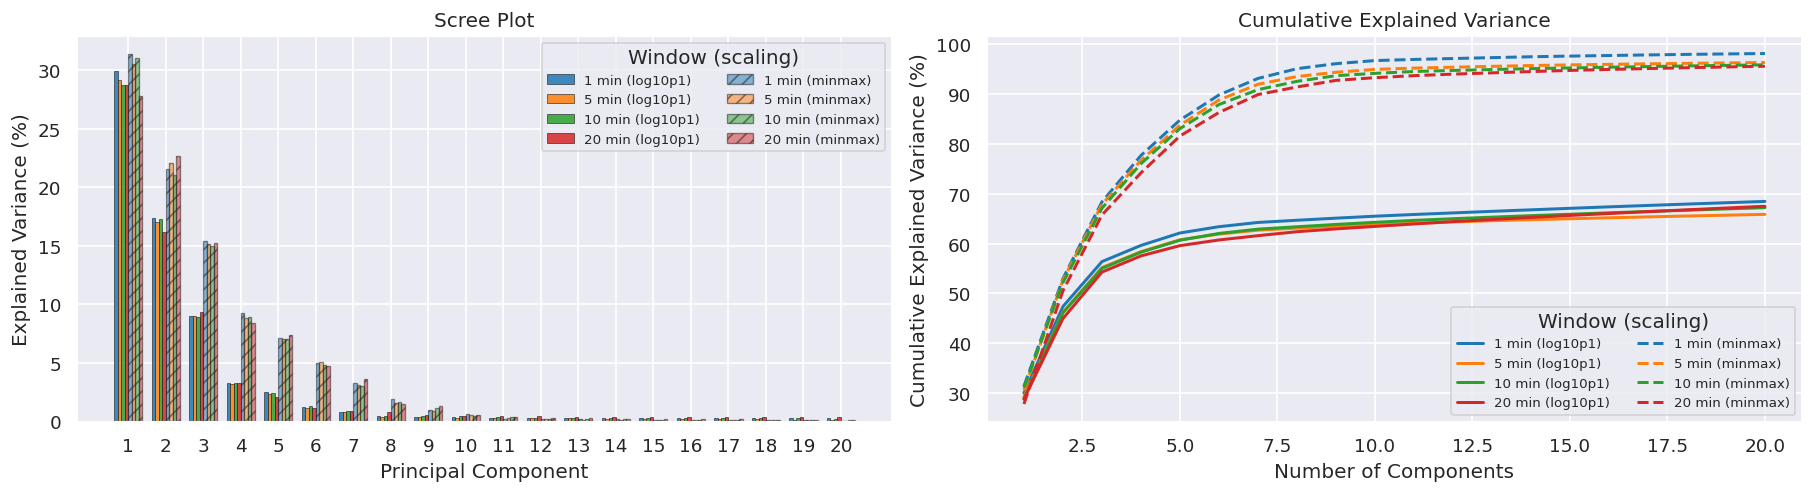

In [7]:
win_palette = dict(zip(N_minutes, sns.color_palette('tab10', len(N_minutes))))
style_map   = {'log10p1':    dict(linestyle='-',  hatch='',    alpha_bar=0.85, lw_edge=0.4),
               'minmax':   dict(linestyle='--', hatch='///',  alpha_bar=0.5,  lw_edge=0.8)}

fig, axes = plt.subplots(1, 2, figsize=(15, 4), layout='constrained')

# ── Left: scree plot ──────────────────────────────────────────────────────
ax = axes[0]
n_win     = len(N_minutes)
n_scaling = len(SCALINGS)
bar_w     = 0.75 / (n_win * n_scaling)

for s_idx, scaling in enumerate(SCALINGS):
    for w_idx, win in enumerate(N_minutes):
        sub   = df_both[(df_both['Scaling'] == scaling) & (df_both['Window (min)'] == win)]
        color = win_palette[win]
        style = style_map[scaling]
        offset = (s_idx * n_win + w_idx - (n_win * n_scaling - 1) / 2) * bar_w
        label  = f'{win} min ({scaling})' if True else None
        ax.bar(sub['Component'] + offset, sub['Explained Variance (%)'],
               width=bar_w, color=color, alpha=style['alpha_bar'],
               hatch=style['hatch'], edgecolor='k', linewidth=style['lw_edge'],
               label=label)

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot')
ax.set_xticks(range(1, N_COMP + 1))
ax.legend(ncol=2, fontsize=8, title='Window (scaling)')

# ── Right: cumulative explained variance ──────────────────────────────────
ax = axes[1]
for scaling in SCALINGS:
    style = style_map[scaling]
    for win in N_minutes:
        sub   = df_both[(df_both['Scaling'] == scaling) & (df_both['Window (min)'] == win)].sort_values('Component')
        color = win_palette[win]
        ax.plot(sub['Component'], sub['Cumulative (%)'],
            color=color, linestyle=style['linestyle'], linewidth=1.8,
                label=f'{win} min ({scaling})')

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance')
ax.legend(ncol=2, fontsize=8, title='Window (scaling)', loc='lower right')
plt.savefig(figure_path / '02_pca_explained_variance.png', bbox_inches='tight')

## 5 · Pair Plots of the First Three PCs — Scaling Comparison

Do the two scaling strategies produce different cluster structures in PC space? Here we fit a PCA model for each scaling on the same balanced 10-minute dataset (120 windows per class, 480 total) and plot all three PC pairs.

If the regions separate cleanly under both scalings the choice is unlikely to matter much downstream. If one scaling produces tighter, better-separated clusters, it is the better preprocessing choice for classification and clustering tasks.

In [8]:
N_PCS_VIZ = 5   # number of PC vectors to visualise (used in §5 and §6)

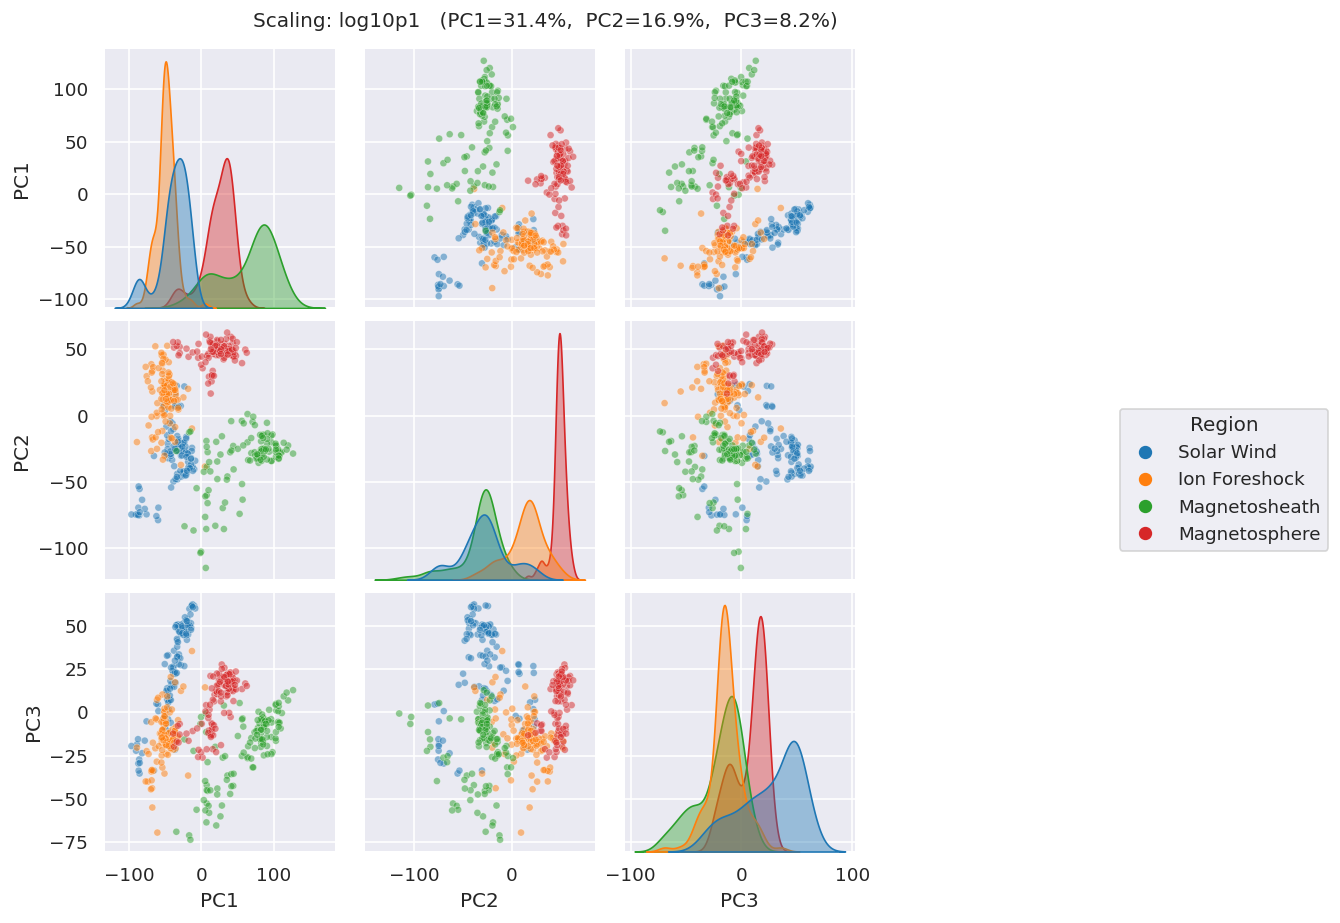

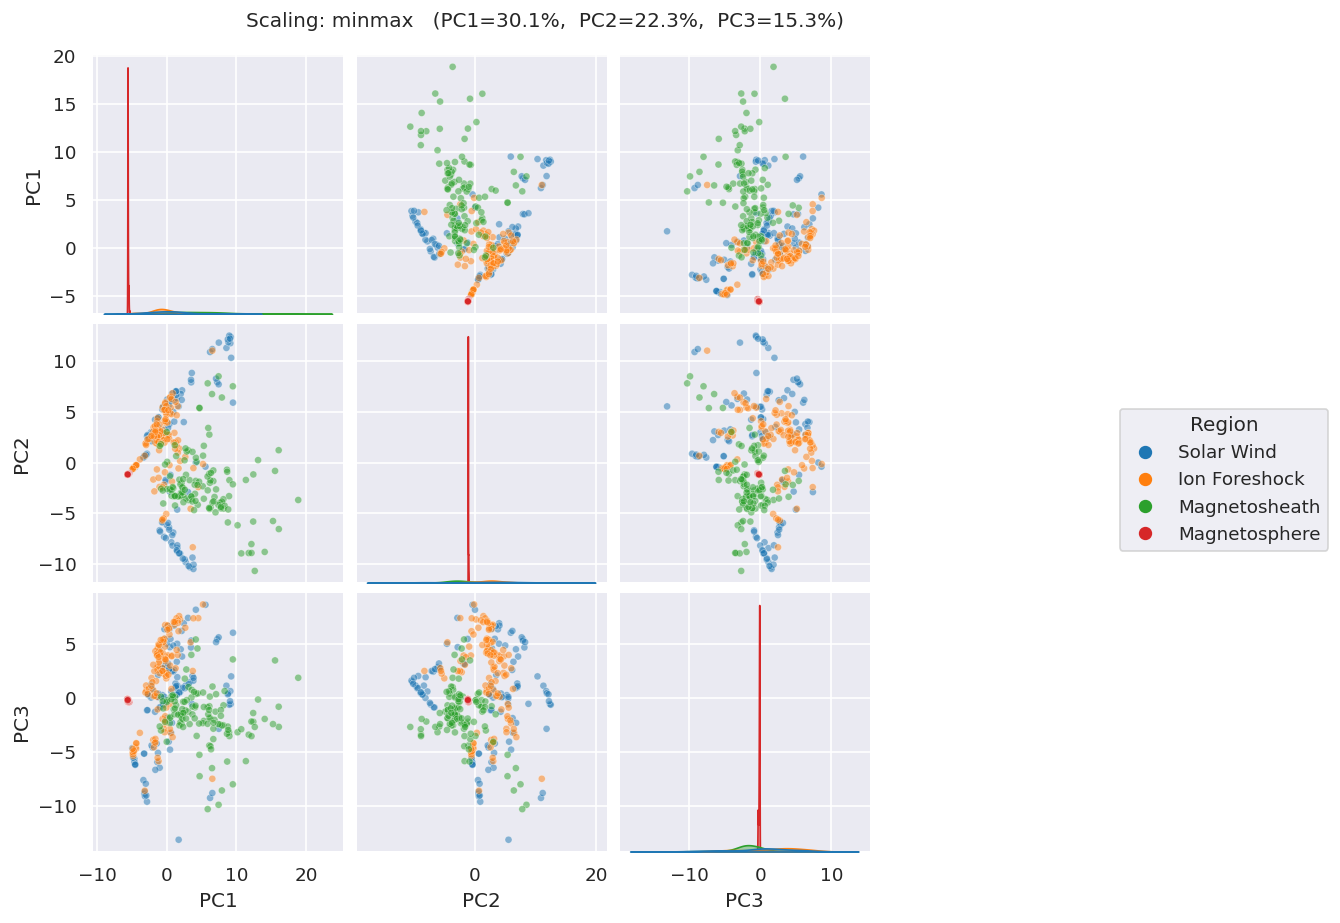

In [9]:
# Load one shared balanced dataset (raw, unscaled)
ds_pair = SpectrumDataset(
    dataset_path=NC_FILE, trange=None,
    N=133, samples=120, data_columns=None,
    flatten=True, verbose=False,
)
X_raw_pair, y_pair = ds_pair[:]
X_raw_pair = X_raw_pair.numpy()
y_pair     = y_pair.numpy()
region_labels = [REGION_NAMES[l] for l in y_pair]

pca_fits   = {}   # scaling → fitted PCA
df_pca     = {}   # scaling → DataFrame with PC1/PC2/PC3/Region

for scaling in SCALINGS:
    X_scaled = preprocess(X_raw_pair, scaling=scaling)
    pca_s    = PCA(n_components=N_PCS_VIZ, random_state=RANDOM_STATE).fit(X_scaled)
    X_proj   = pca_s.transform(X_scaled)
    pca_fits[scaling] = pca_s
    df_pca[scaling]   = pd.DataFrame(X_proj[:, :3], columns=['PC1', 'PC2', 'PC3'])
    df_pca[scaling]['Region'] = region_labels

# Fixed legend handles (shared across both grids)
legend_handles = [
    mlines.Line2D([], [], color=PALETTE[name], marker='o', linestyle='',
                  markersize=7, label=name)
    for name in REGION_NAMES.values()
]

for scaling in SCALINGS:
    g = sns.pairplot(
        df_pca[scaling], hue='Region', hue_order=list(REGION_NAMES.values()),
        plot_kws={'alpha': 0.5, 's': 18},
        diag_kws={'fill': True, 'alpha': 0.4},
        palette=PALETTE, corner=False,
    )
    evr_s = pca_fits[scaling].explained_variance_ratio_
    g.figure.suptitle(
        f"Scaling: {scaling}   "
        f"(PC1={evr_s[0]*100:.1f}%,  PC2={evr_s[1]*100:.1f}%,  PC3={evr_s[2]*100:.1f}%)",
        y=1.02, fontsize=12,
    )
    g.legend.remove()
    g.figure.legend(handles=legend_handles, title='Region',
                    bbox_to_anchor=(1.01, 0.5), loc='center left', frameon=True)
    
    plt.savefig(figure_path / f'02_pca_pair_plot_scaling_{scaling}.png', bbox_inches='tight')

## 6 · Principal Component Vectors as Spectrograms

Each principal component is a weight vector of length `N × n_bins` — the same size as a flattened window (here 133 time steps × 32 energy bins = 4,256 values). Reshaping it back to `(133, 32)` lets us display it as a spectrogram, with time on the x-axis and energy (eV) on the y-axis, directly comparable to the raw data in §2.

The colour scale is diverging (red = positive loading, blue = negative): a red patch at a given energy and time means that high flux there *increases* the projection onto this PC; blue means it *decreases* it.

- **PC1** captures the dominant overall flux structure — the pattern shared by most windows regardless of region.
- **PC2 and PC3** encode the leading *contrasts* between regions: where one region is bright, another is dim.
- **Higher PCs** pick up progressively finer time- or energy-localised differences, eventually reaching noise.

Comparing the two columns shows whether `log10p1` and `minmax` identify the same physical structures or emphasise different aspects of the data.

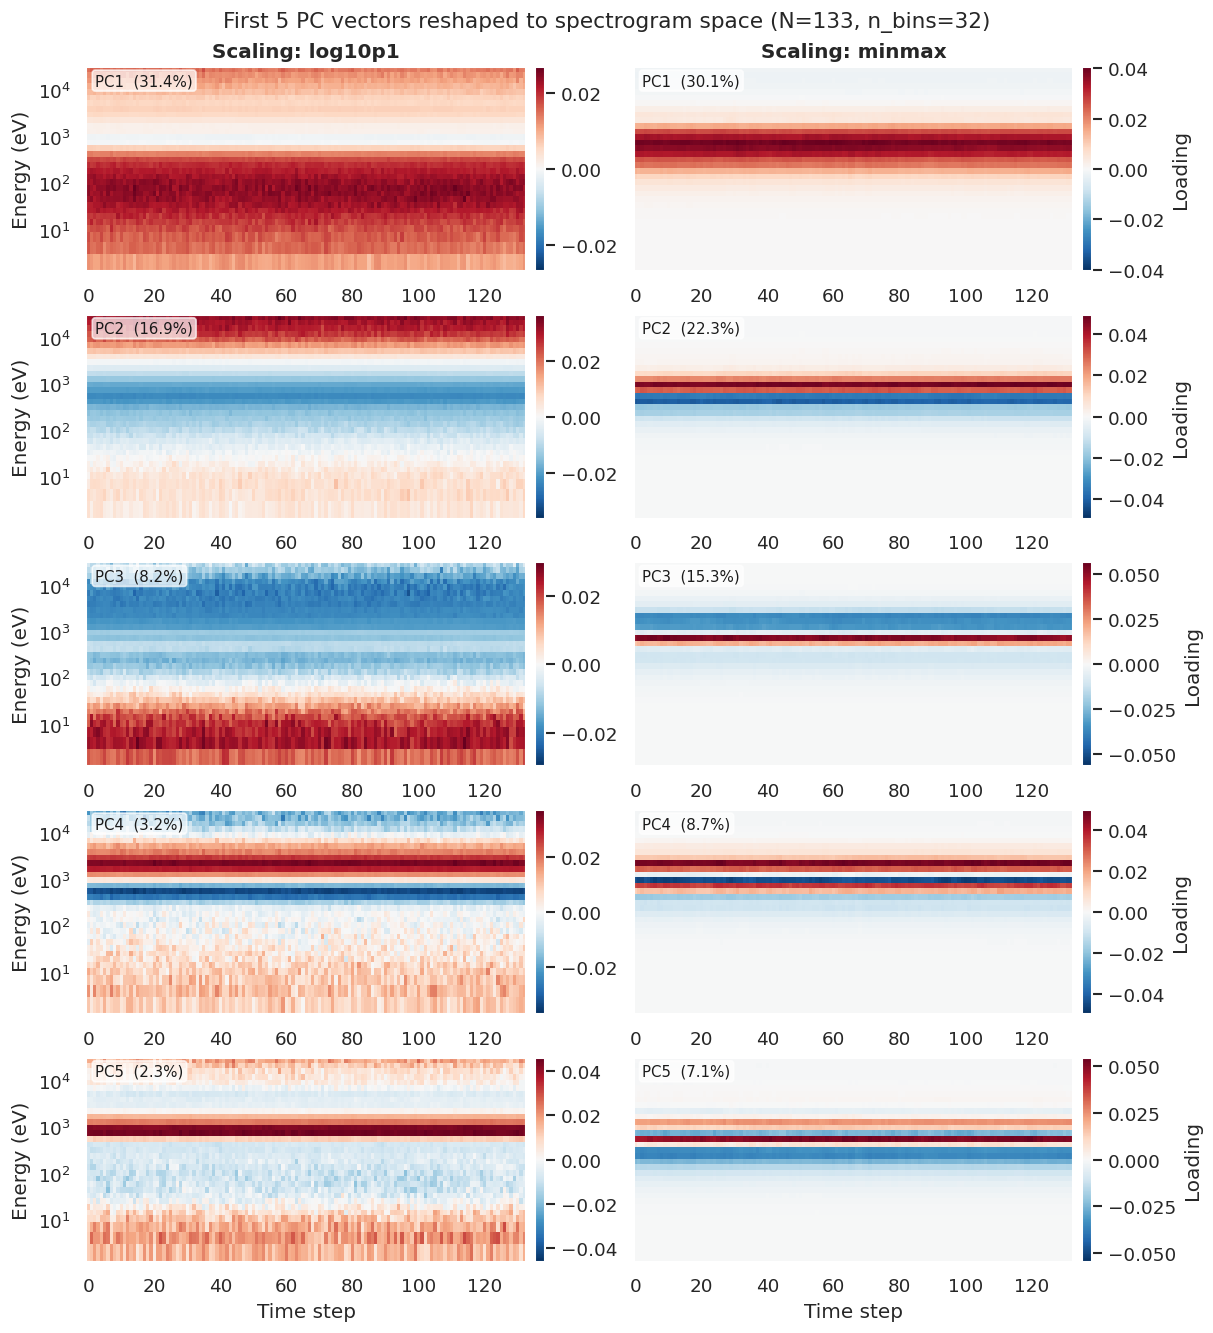

In [10]:
# Energy bin centres and number of time steps (N) from the dataset
# ds.bin_centers has shape (samples, time_steps, n_bins) — take one row
spec_lev  = ds.bin_centers[0, 0]          # (n_bins,)
n_bins    = len(spec_lev)
time_axis = np.arange(N)

fig, axes = plt.subplots(
    N_PCS_VIZ, len(SCALINGS),
    figsize=(5 * len(SCALINGS), 2.2 * N_PCS_VIZ),
    sharey=True, layout='constrained',
)

for col, scaling in enumerate(SCALINGS):
    components = pca_fits[scaling].components_   # (3, N*n_bins)

    for row in range(N_PCS_VIZ):
        ax  = axes[row, col]
        vec = components[row].reshape(N, n_bins)  # (N, n_bins)

        # Symmetric colour scale centred on zero so positive/negative
        # loadings are equally visible
        vmax = np.abs(vec).max()
        im   = ax.pcolormesh(
            time_axis, spec_lev, vec.T,
            cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto',
        )
        ax.set_yscale('log')
        ax.set_ylabel('Energy (eV)' if col == 0 else '')
        ax.set_xlabel('Time step' if row == N_PCS_VIZ - 1 else '')

        if row == 0:
            ax.set_title(f'Scaling: {scaling}', fontsize=12, fontweight='bold')

        evr_s  = pca_fits[scaling].explained_variance_ratio_
        pc_var = evr_s[row] * 100 if row < len(evr_s) else 0
        ax.text(0.02, 0.97, f'PC{row+1}  ({pc_var:.1f}%)',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=9, color='k',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

        fig.colorbar(im, ax=ax, pad=0.02, fraction=0.04,
                     label='Feature significans' if col == len(SCALINGS)-1 else '')

fig.suptitle(
    f'First {N_PCS_VIZ} PC vectors reshaped to spectrogram space (N={N}, n_bins={n_bins})',
    fontsize=13,
)
plt.savefig(figure_path / '02_pca_component_vectors.png', bbox_inches='tight')

## Summary

- **Ion spectra are visually distinct** across the four plasma regions. Solar Wind and Ion Foreshock show narrow peaks at high energies (~10 keV); Magnetosheath has a broad medium-energy peak; Magnetosphere flux is lower overall (~10⁶ vs ~10⁸) and more uniformly distributed.
- **Class imbalance** reflects MMS's orbital geometry: in this dataset Solar Wind dominates with 947 windows, followed by Magnetosheath (821), Magnetosphere (314), and Ion Foreshock (208) — a roughly 4:1 ratio between the most and least common class. Always balance classes before training.
- **Preprocessing matters:** ion flux spans ~8 decades of dynamic range. Without scaling, high-flux regions (SW, MSH, IF) dominate PCA entirely. Both `log10p1` and `minmax` compress this range while preserving the spectral shape across energy channels.
- **Both scaling strategies agree on compressibility:** the scree curves have the same qualitative shape under both scalings — the number of components needed to reach a given explained-variance threshold is consistent between them.
- **Window length drives dimensionality:** shorter windows (1 min) are more compressible; longer windows (20 min) encode temporal evolution and require more components to represent faithfully.
- **The first 3 PCs already separate the regions** in the pair plot under both scalings, giving confidence that the downstream clustering in notebook 03 is robust to this preprocessing choice.
- **PC vectors as spectrograms** reveal the physical meaning of each component.

### Further reading
- Toy-Edens et al. (2024) – *Classifying 8 years of MMS dayside plasma regions via unsupervised ML*, JGR Space Physics.
- Olshevsky et al. (2021) – supervised neural-network region identification from MMS ion spectra; includes PC vector visualisation.
- [scikit-learn PCA documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)